# Diabetes Risk Prediction Using Machine Learning

## Step 1: Data Cleaning and Exploratory Data Analysis

This notebook prepares and explores the diabetes dataset for a machine learning classification project.

The goal of this step is to clean the dataset, handle invalid medical values, understand the target distribution, explore key risk factors, and export a cleaned dataset for model training.

> **Healthcare Disclaimer:** This project is for educational and analytical purposes only. It is not intended for clinical diagnosis or medical decision-making.


## 1. Business / Healthcare Problem

Diabetes risk prediction is a classification problem where the goal is to identify whether a patient is likely to have diabetes based on available health indicators.

The main analytical question is:

> Which patient health indicators are most associated with diabetes risk?

This project uses the dataset to explore risk patterns and prepare the data for machine learning modeling in Step 2.


## 2. Dataset Overview

The dataset contains patient health measurements and a binary target variable named `Outcome`.

| Column | Description |
|---|---|
| `Pregnancies` | Number of pregnancies |
| `Glucose` | Plasma glucose concentration |
| `BloodPressure` | Diastolic blood pressure |
| `SkinThickness` | Triceps skin fold thickness |
| `Insulin` | 2-hour serum insulin |
| `BMI` | Body Mass Index |
| `DiabetesPedigreeFunction` | Diabetes pedigree score |
| `Age` | Patient age |
| `Outcome` | Target variable, 0 = No Diabetes, 1 = Diabetes |


In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
# Load dataset

df = pd.read_csv("../data/raw/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [3]:
# Dataset shape and basic information

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 768
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 3. Missing Values and Invalid Zero Values

The dataset does not contain standard missing values. However, some medical measurements contain zero values that are not biologically realistic.

For example, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` should not normally be zero. These zero values are treated as missing data and imputed using the median value of each column.


In [6]:
# Standard missing values

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check invalid zero values in medical measurement columns

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_summary = pd.DataFrame({
    "feature": invalid_zero_cols,
    "zero_count": [int((df[col] == 0).sum()) for col in invalid_zero_cols],
    "zero_percentage": [round((df[col] == 0).mean() * 100, 2) for col in invalid_zero_cols]
})

zero_summary

,feature,zero_count,zero_percentage
0,Glucose,5,0.65
1,BloodPressure,35,4.56
2,SkinThickness,227,29.56
3,Insulin,374,48.70
4,BMI,11,1.43


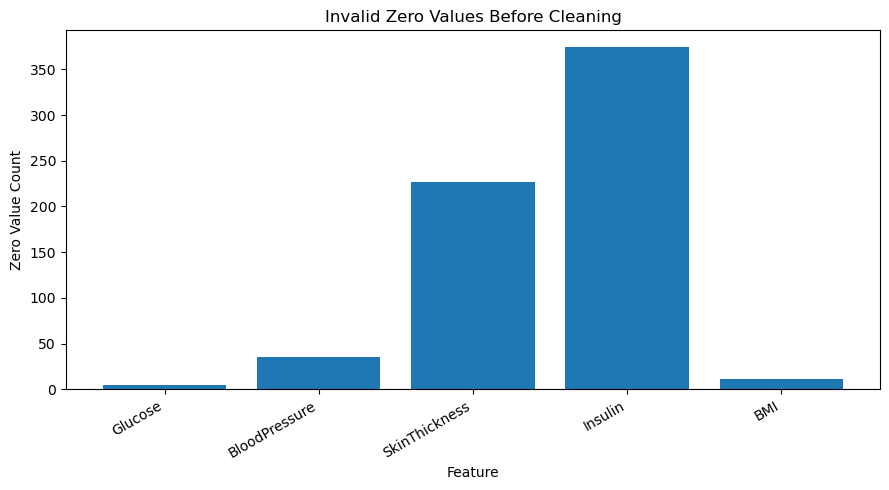

In [9]:
# Visualize invalid zero values

zero_counts = df[invalid_zero_cols].eq(0).sum()

plt.figure(figsize=(9, 5))
plt.bar(zero_counts.index, zero_counts.values)
plt.title("Invalid Zero Values Before Cleaning")
plt.xlabel("Feature")
plt.ylabel("Zero Value Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../images/invalid_zero_values.png", dpi=150)
plt.show()

## 4. Data Cleaning

Median imputation is used because medical variables such as insulin and skin thickness can be skewed and may contain outliers. The median is more robust than the mean for these distributions.


In [10]:
# Replace invalid zero values with NaN, then impute using median

df_clean = df.copy()

for col in invalid_zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean[invalid_zero_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,768.00,121.66,30.44,44.00,99.75,117.00,140.25,199.00
BloodPressure,768.00,72.39,12.10,24.00,64.00,72.00,80.00,122.00
SkinThickness,768.00,29.11,8.79,7.00,25.00,29.00,32.00,99.00
Insulin,768.00,140.67,86.38,14.00,121.50,125.00,127.25,846.00
BMI,768.00,32.46,6.88,18.20,27.50,32.30,36.60,67.10


In [11]:
# Confirm invalid zeros were handled

df_clean[invalid_zero_cols].eq(0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

## 5. Feature Engineering

New categorical features are created to support EDA and dashboard analysis:

- `glucose_category`
- `bmi_category`
- `age_group`
- `risk_label`


In [12]:
# Create helpful categorical features

df_clean["glucose_category"] = pd.cut(
    df_clean["Glucose"],
    bins=[0, 99, 125, np.inf],
    labels=["Normal", "Prediabetes Range", "Diabetes Range"]
)

df_clean["bmi_category"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 24.9, 29.9, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_clean["age_group"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"],
    include_lowest=True
)

df_clean["risk_label"] = df_clean["Outcome"].map({0: "No Diabetes", 1: "Diabetes"})

df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,glucose_category,bmi_category,age_group,risk_label
0,6,148.00,72.00,35.00,125.00,33.60,0.63,50,1,Diabetes Range,Obese,41-50,Diabetes
1,1,85.00,66.00,29.00,125.00,26.60,0.35,31,0,Normal,Overweight,31-40,No Diabetes
2,8,183.00,64.00,29.00,125.00,23.30,0.67,32,1,Diabetes Range,Normal,31-40,Diabetes
3,1,89.00,66.00,23.00,94.00,28.10,0.17,21,0,Normal,Overweight,21-30,No Diabetes
4,0,137.00,40.00,35.00,168.00,43.10,2.29,33,1,Diabetes Range,Obese,31-40,Diabetes


## 6. Class Balance Analysis

The target variable is moderately imbalanced. There are more patients without diabetes than patients with diabetes.

Because of this imbalance, model evaluation in Step 2 should not rely only on accuracy. Precision, recall, F1-score, and ROC-AUC should also be used.


In [13]:
# Outcome distribution

outcome_summary = df_clean["risk_label"].value_counts().rename_axis("risk_label").reset_index(name="patient_count")
outcome_summary["percentage"] = (outcome_summary["patient_count"] / len(df_clean) * 100).round(2)

outcome_summary

,risk_label,patient_count,percentage
0,No Diabetes,500,65.10
1,Diabetes,268,34.90


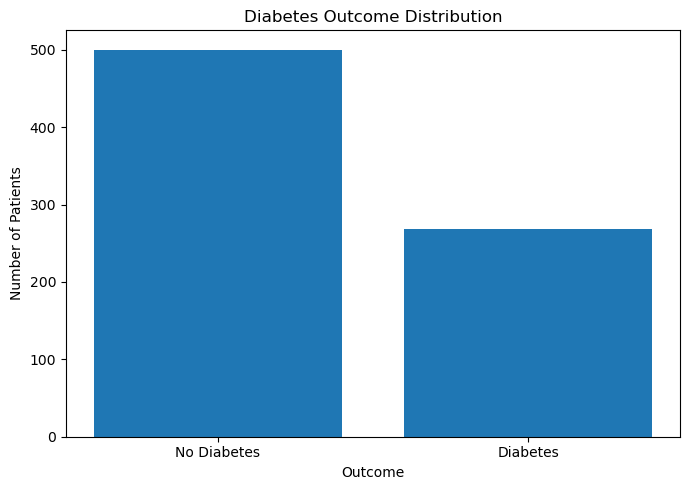

In [14]:
# Outcome distribution chart

counts = df_clean["risk_label"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("../images/outcome_distribution.png", dpi=150)
plt.show()

## 7. Exploratory Data Analysis

The EDA focuses on identifying how important health indicators differ between patients with and without diabetes.


In [15]:
# Average feature values by outcome

feature_summary = df_clean.groupby("risk_label", observed=False)[
    ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
].mean().round(2)

feature_summary

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
risk_label,,,,,,,,
Diabetes,4.87,142.13,75.12,31.69,164.70,35.38,0.55,37.07
No Diabetes,3.30,110.68,70.92,27.73,127.79,30.89,0.43,31.19


C:\Users\ragha\AppData\Local\Temp\ipykernel_15720\636633887.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])


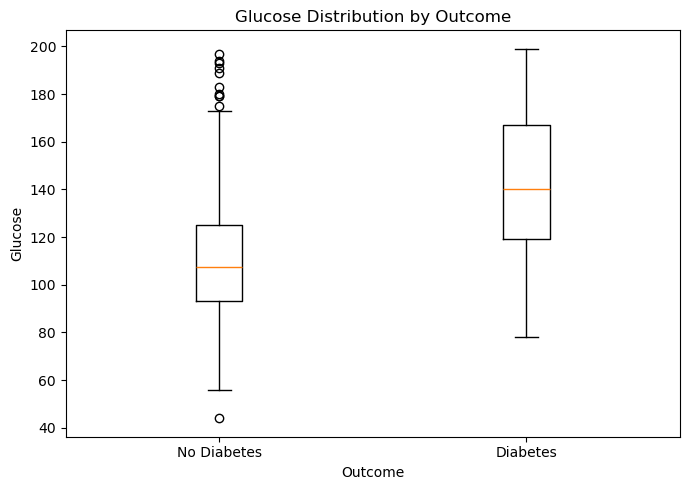

In [16]:
# Glucose distribution by outcome

groups = [
    df_clean[df_clean["risk_label"] == "No Diabetes"]["Glucose"],
    df_clean[df_clean["risk_label"] == "Diabetes"]["Glucose"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])
plt.title("Glucose Distribution by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.tight_layout()
plt.savefig("../images/glucose_by_outcome.png", dpi=150)
plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_15720\3361461544.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])


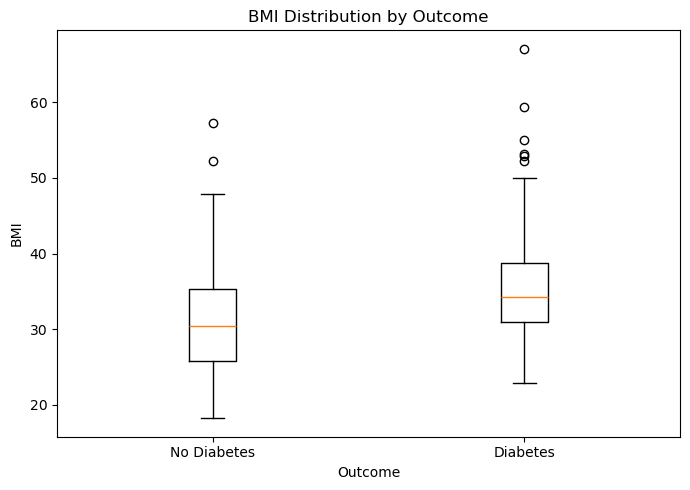

In [17]:
# BMI distribution by outcome

groups = [
    df_clean[df_clean["risk_label"] == "No Diabetes"]["BMI"],
    df_clean[df_clean["risk_label"] == "Diabetes"]["BMI"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])
plt.title("BMI Distribution by Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.tight_layout()
plt.savefig("../images/bmi_by_outcome.png", dpi=150)
plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_15720\3935393387.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])


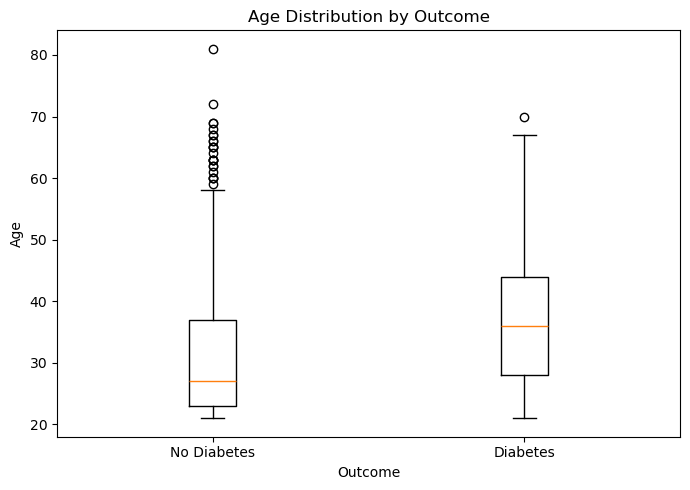

In [18]:
# Age distribution by outcome

groups = [
    df_clean[df_clean["risk_label"] == "No Diabetes"]["Age"],
    df_clean[df_clean["risk_label"] == "Diabetes"]["Age"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(groups, labels=["No Diabetes", "Diabetes"])
plt.title("Age Distribution by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("../images/age_by_outcome.png", dpi=150)
plt.show()

In [19]:
# Glucose category distribution

glucose_category_summary = pd.crosstab(
    df_clean["glucose_category"],
    df_clean["risk_label"],
    normalize="index"
).round(3) * 100

glucose_category_summary

risk_label,Diabetes,No Diabetes
glucose_category,,
Normal,7.30,92.70
Prediabetes Range,28.00,72.00
Diabetes Range,59.30,40.70


In [20]:
# BMI category distribution

bmi_category_summary = pd.crosstab(
    df_clean["bmi_category"],
    df_clean["risk_label"],
    normalize="index"
).round(3) * 100

bmi_category_summary

risk_label,Diabetes,No Diabetes
bmi_category,,
Underweight,0.00,100.00
Normal,6.90,93.10
Overweight,22.30,77.70
Obese,45.80,54.20


## 8. Correlation Analysis

Correlation analysis helps identify which numeric features have stronger relationships with the target variable.


In [21]:
# Correlation with Outcome

numeric_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

correlation_with_outcome = df_clean[numeric_cols].corr()["Outcome"].sort_values(ascending=False)
correlation_with_outcome

Outcome                    1.00
Glucose                    0.49
BMI                        0.31
Age                        0.24
Pregnancies                0.22
SkinThickness              0.21
Insulin                    0.20
DiabetesPedigreeFunction   0.17
BloodPressure              0.17
Name: Outcome, dtype: float64

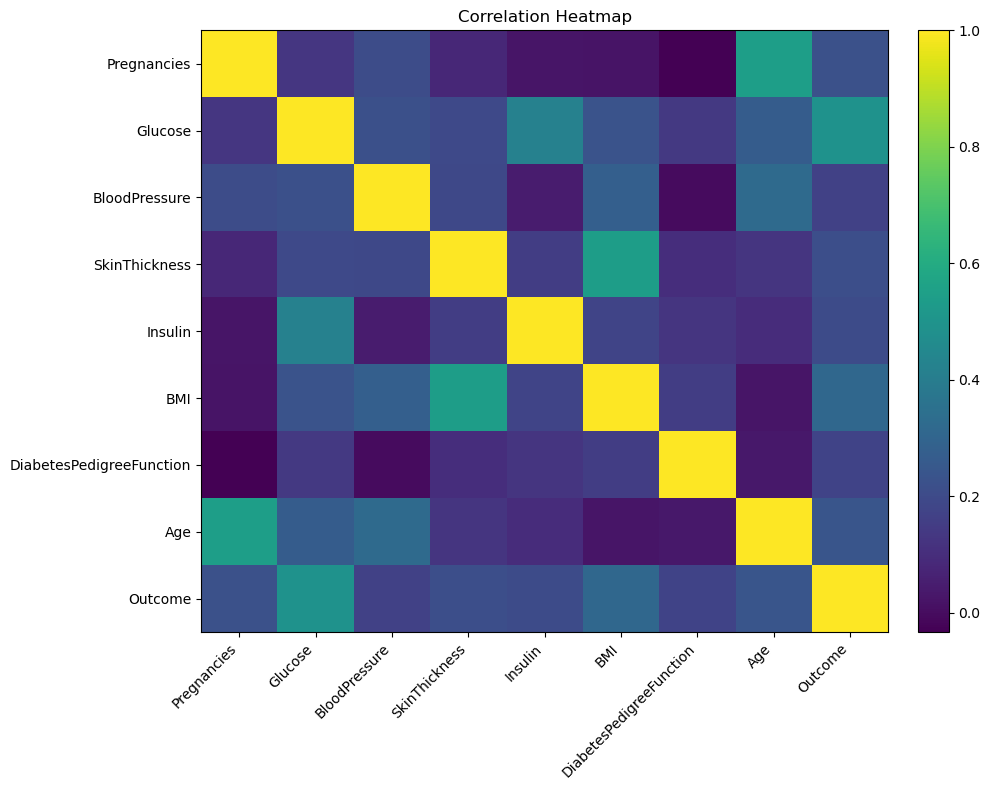

In [22]:
# Correlation heatmap

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=150)
plt.show()

## 9. Key EDA Insights

Based on the exploratory analysis:

- Patients with diabetes tend to have higher glucose levels.
- BMI is generally higher among patients with diabetes.
- Age and number of pregnancies show noticeable differences between the two outcome groups.
- The dataset is moderately imbalanced, so model evaluation should include recall, F1-score, and ROC-AUC.
- Invalid zero values were present in important medical measurements and were handled before modeling.

These cleaned data and insights will be used in Step 2 for machine learning model training and evaluation.


## 10. Export Cleaned Data

The cleaned dataset and summary files are saved for machine learning and dashboard preparation.


In [23]:
# Export cleaned dataset and summary files

df_clean.to_csv("../data/processed/diabetes_cleaned.csv", index=False)

outcome_summary.to_csv("../data/processed/outcome_summary.csv", index=False)

feature_summary.reset_index().to_csv("../data/processed/feature_summary_by_outcome.csv", index=False)

print("Cleaned dataset and summary files exported successfully.")

Cleaned dataset and summary files exported successfully.
